# Tutorial 11 — Defect types across production lines

## 1. Problem / context

Each recorded defect is one observational unit, labelled by production line (`L1`, `L2`, `L3`) and defect type (`solder`, `alignment`, `contamination`, `other`). The file is `defect_types.csv`. Operations wants to know whether the **mix** of defect types differs by line, and whether the overall mix matches a historical standard.

These are **counts**, not micrometres. Brooks Chapter 11 is the theory: goodness of fit, independence versus homogeneity, expected counts, residuals, and Cramér’s $V$.

## 2. What we will compute

Chi-square calculations use **counts**. A table of percentages is not an input to $\chi^2$.

**Goodness of fit** compares one categorical variable with specified probabilities. We use a historical mix, stated in advance:

$$
P(\text{solder})=0.45,\;
P(\text{alignment})=0.25,\;
P(\text{contamination})=0.20,\;
P(\text{other})=0.10.
$$

Expected counts are $n\times p_j$. Degrees of freedom are $k-1=3$ because these probabilities are **not** estimated from the same table.

**Independence versus homogeneity.** The Pearson calculation can be the same. The design is not. Independence: one sample of defects, two classifications. Homogeneity: separate samples from each line, compare defect-type distributions. These data are recorded by line, so the natural reading is **homogeneity** of defect profiles across lines.

$$
E_{ij}=\frac{(\text{row $i$ total})\times(\text{column $j$ total})}{n},
\qquad
\chi^2=\sum_{i,j}\frac{(O_{ij}-E_{ij})^2}{E_{ij}}.
$$

Pearson residuals $(O-E)/\sqrt{E}$ and **adjusted** residuals locate the cells that drive a global result. Cramér’s $V=\sqrt{\chi^2/(n\min(r-1,c-1))}$ is an effect magnitude with no universal engineering cutoff.

A significant table is not a root-cause analysis and does not establish causation. Chi-square GOF on **binned continuous** measurements is not the course’s normality assessment; that remains QQ-plots and Shapiro–Wilk from Chapter 7.

## 3. Python implementation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import chi2_contingency, chisquare, chi2

candidates = [Path("data"), Path("../data"), Path.cwd() / "data"]
DATA = next(p for p in candidates if p.exists())
df = pd.read_csv(DATA / "defect_types.csv")
print(df.head())
print(df.shape)


  line    defect_type
0   L1  contamination
1   L1  contamination
2   L1         solder
3   L1  contamination
4   L1      alignment
(360, 2)


### Goodness of fit against the historical mix


In [2]:
order = ["solder", "alignment", "contamination", "other"]
p0 = np.array([0.45, 0.25, 0.20, 0.10])
counts = df["defect_type"].value_counts().reindex(order)
n = int(counts.sum())
expected_gof = n * p0
gof = chisquare(counts.to_numpy(), f_exp=expected_gof)
gof_table = pd.DataFrame(
    {"observed": counts.to_numpy(), "expected": expected_gof, "p0": p0},
    index=order,
)
print(gof_table)
print(f"chi2 = {gof.statistic:.2f}, df = {len(order) - 1}, p = {gof.pvalue:.4g}")


               observed  expected    p0
solder              128     162.0  0.45
alignment           109      90.0  0.25
contamination        81      72.0  0.20
other                42      36.0  0.10
chi2 = 13.27, df = 3, p = 0.004084


Pause: if the GOF $p$-value is small, does that tell you **which** type departed from the historical mix?

### Contingency table: homogeneity of lines


In [3]:
table = pd.crosstab(df["line"], df["defect_type"]).reindex(columns=order)
print("observed counts:\n", table)
print("row proportions:\n", table.div(table.sum(axis=1), axis=0).round(3))


observed counts:
 defect_type  solder  alignment  contamination  other
line                                                
L1               43         26             35     16
L2               42         39             22     17
L3               43         44             24      9
row proportions:
 defect_type  solder  alignment  contamination  other
line                                                
L1            0.358      0.217          0.292  0.133
L2            0.350      0.325          0.183  0.142
L3            0.358      0.367          0.200  0.075


In [4]:
chi2_stat, p_val, dof, expected = chi2_contingency(table, correction=False)
expected_df = pd.DataFrame(expected, index=table.index, columns=table.columns)
print("expected counts:\n", expected_df.round(2))
print("minimum expected count:", expected.min())
print(f"chi2 = {chi2_stat:.2f}, df = {dof}, p = {p_val:.4g}")


expected counts:
 defect_type  solder  alignment  contamination  other
line                                                
L1            42.67      36.33           27.0   14.0
L2            42.67      36.33           27.0   14.0
L3            42.67      36.33           27.0   14.0
minimum expected count: 14.0
chi2 = 11.11, df = 6, p = 0.08498


Degrees of freedom are $(r-1)(c-1)=6$. No probability was estimated beyond the table margins that the test already uses.


In [5]:
row_tot = table.sum(axis=1).to_numpy()[:, None]
col_tot = table.sum(axis=0).to_numpy()[None, :]
N = table.to_numpy().sum()
pearson_resid = (table.to_numpy() - expected) / np.sqrt(expected)
adj_resid = (table.to_numpy() - expected) / np.sqrt(
    expected * (1 - row_tot / N) * (1 - col_tot / N)
)
pearson_df = pd.DataFrame(pearson_resid, index=table.index, columns=table.columns)
adj_df = pd.DataFrame(adj_resid, index=table.index, columns=table.columns)
print("Pearson residuals:\n", pearson_df.round(2))
print("adjusted residuals:\n", adj_df.round(2))
V = np.sqrt(chi2_stat / (N * min(table.shape[0] - 1, table.shape[1] - 1)))
print(f"Cramér's V = {V:.3f}")


Pearson residuals:
 defect_type  solder  alignment  contamination  other
line                                                
L1             0.05      -1.71           1.54   0.53
L2            -0.10       0.44          -0.96   0.80
L3             0.05       1.27          -0.58  -1.34
adjusted residuals:
 defect_type  solder  alignment  contamination  other
line                                                
L1             0.08      -2.51           2.14   0.70
L2            -0.16       0.65          -1.34   1.04
L3             0.08       1.87          -0.80  -1.74
Cramér's V = 0.124


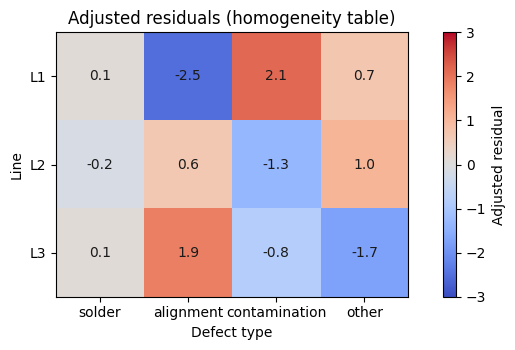

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.6))
im = ax.imshow(adj_resid, cmap="coolwarm", vmin=-3, vmax=3)
ax.set_xticks(range(len(order)), order)
ax.set_yticks(range(len(table.index)), table.index)
ax.set_xlabel("Defect type")
ax.set_ylabel("Line")
ax.set_title("Adjusted residuals (homogeneity table)")
for i in range(adj_resid.shape[0]):
    for j in range(adj_resid.shape[1]):
        ax.text(j, i, f"{adj_resid[i, j]:.1f}", ha="center", va="center", color="0.1")
fig.colorbar(im, ax=ax, label="Adjusted residual")
plt.tight_layout()
plt.show()


If some expected counts were below about 5, we would pool only when the merged category is **substantively** meaningful, and not because a cell was inconvenient. Here we check the minimum expected count first.

### A short Monte Carlo check under the null

The theoretical $\chi^2$ tail is an approximation. A seeded permutation of line labels, holding defect types fixed, simulates the homogeneity/independence null.


In [7]:
rng = np.random.default_rng(2026)
obs = table.to_numpy()
n_perm = 5000
sim = np.empty(n_perm)
lines = df["line"].to_numpy()
types = df["defect_type"].to_numpy()
for i in range(n_perm):
    shuf = rng.permutation(lines)
    tab = pd.crosstab(shuf, types).reindex(index=table.index, columns=order)
    sim[i] = chi2_contingency(tab, correction=False)[0]
p_mc = (1 + np.sum(sim >= chi2_stat)) / (n_perm + 1)
print(f"Monte Carlo p-value (plus-one rule) = {p_mc:.4g}")
print(f"chi-square reference p-value        = {p_val:.4g}")


Monte Carlo p-value (plus-one rule) = 0.08758
chi-square reference p-value        = 0.08498


This is a check, not the main method. For a sparse $2\times 2$ table, Fisher’s exact test is the usual small-sample alternative; we do not need it for this $3\times 4$ table.

## 4. Interpretation

Follow the Chapter 11 nine-step order: population, unit, variables, design; GOF versus homogeneity; observed counts and conditional proportions; $H_0$ and $H_1$; expected counts and df; adequacy of the approximation; $\chi^2$, df, $p$; residuals, $V$; conclusion in the language of defect types, not only $\chi^2$.

The goodness-of-fit analysis gives $\chi^2(3)=13.27$ and $p\approx0.004$. The recorded overall defect mix is therefore difficult to reconcile with the historical 45%/25%/20%/10% distribution. The observed table contains fewer solder defects and more alignment defects than that historical model expects. This is evidence that the overall mix has changed; it does not identify why.

The homogeneity analysis gives $\chi^2(6)=11.11$, $p\approx0.085$, and Cramér's $V\approx0.124$. At $\alpha=0.05$, the data do not provide sufficient evidence that the defect-type distributions differ among the three production lines. The largest adjusted residuals occur for alignment and contamination on L1, but after a non-significant global test they remain descriptive leads for investigation, not confirmed line-specific differences.

Even if a later and larger sample established different profiles, the table would show **where** counts differ, not the production mechanism. Root-cause work would still need information about products, shifts, materials, operators, and inspection procedures.

## 5. Common mistakes / things to notice

- Computing $\chi^2$ from percentages instead of counts.
- Treating GOF and a two-way table as the same question.
- Forgetting to reduce df when probabilities are estimated from the same data (not the case in the historical-mix GOF above).
- Pooling categories after seeing which cell was awkward.
- Using chi-square on binned thickness as a normality test.
- Calling a significant table a causal root-cause analysis.
- Treating a cutoff for $V$ as an engineering decision rule.

**Conclusion:** The overall defect mix differs from the stated historical standard, but this sample does not establish different defect profiles across L1, L2, and L3 at the 5% level. Operations should first investigate the overall shift in defect composition and treat the line-level residual pattern as a lead for further data collection, not as a demonstrated root cause.
